[1, 9]
[1, 2, 5, 9]
2.0


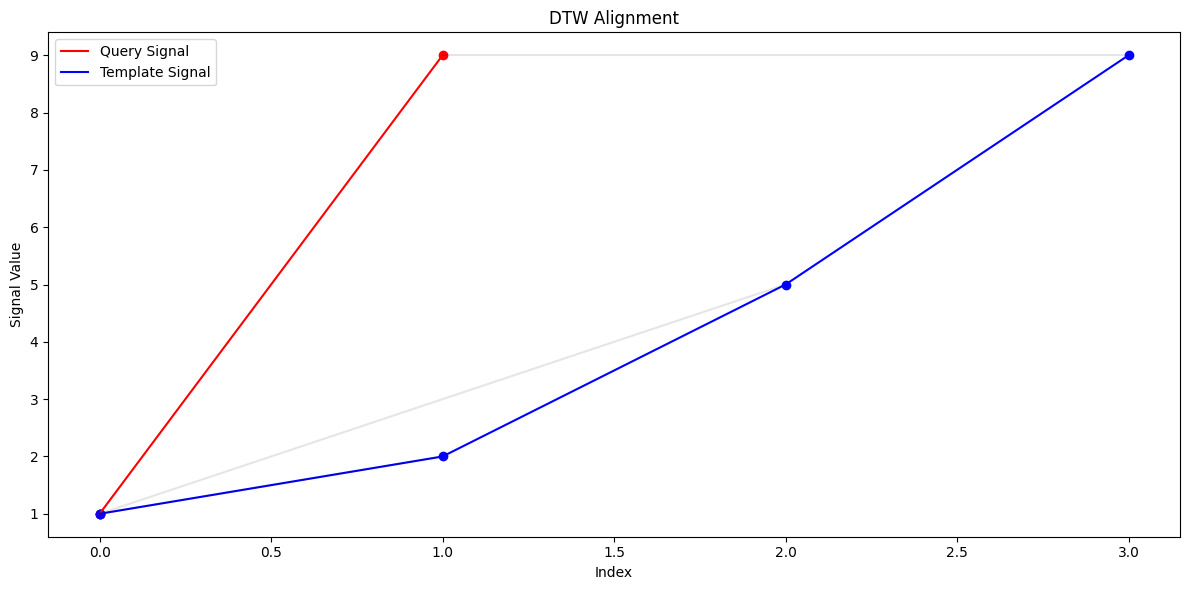

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from dtw import *
from copy import deepcopy


def viz(Q, T, ind1, ind2, fname):
    # Convert to numpy arrays for ease of indexing
    Q = np.array(Q)
    T = np.array(T)

    # Plot the query and template signals with alignment lines
    plt.figure(figsize=(12, 6))
    plt.plot(range(len(Q)), Q, 'r-', label='Query Signal')
    plt.plot(range(len(T)), T, 'b-', label='Template Signal')

    # Plot the alignment lines
    for i, j in zip(ind1, ind2):
        plt.plot([i, j], [Q[i], T[j]], 'k-', alpha=0.1)

    plt.scatter(ind1, Q[ind1], color='red')
    plt.scatter(ind2, T[ind2], color='blue')

    # Labeling the plot
    plt.xlabel('Index')
    plt.ylabel('Signal Value')
    plt.legend()
    plt.title('DTW Alignment')

    plt.tight_layout()
    plt.savefig(fname, dpi = 300)
    plt.show()


def remap_code(D):

    Map, ind = {}, 0
    E = []
    for i in range(len(D)):
        if D.iloc[i]['ICD9_CODE'] not in Map.keys():
            Map[D.iloc[i]['ICD9_CODE']] = ind
            ind = ind + 1

        E.append([D.iloc[i]['SUBJECT_ID'], Map[D.iloc[i]['ICD9_CODE']]])

    return E, Map


def jaccard_similarity(list1, list2):
    s1 = set(list1)
    s2 = set(list2)
    return float(len(s1.intersection(s2)) / len(s1.union(s2)))



# Define the distance metric (e.g., Euclidean distance)
# dist = lambda x, y: np.abs(x - y)
dist = lambda x, y: 0 if x == y else 1

query    = [1, 9,]
template = [1, 2, 5, 9]

alignment = dtw(query, template, dist)
cost, _, _, (ind1, ind2) = deepcopy(alignment)

print (query)
print (template)
print (cost)

viz(query, template, ind1, ind2, 'DTW_Render.png')


{109: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22], 112: [23, 24, 25, 26, 27], 113: [28, 29, 30], 114: [26, 31, 32, 25, 33, 34], 115: [35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52], 116: [53, 54, 55], 117: [56, 57, 58, 10, 44, 59, 60, 46, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 1, 71, 72, 73, 7, 74, 75, 76, 77, 78], 118: [79, 54], 119: [80, 81, 82, 83, 84, 85, 86, 87], 120: [79, 54, 55], 122: [79, 88, 89], 123: [90, 26, 46, 61, 34], 124: [91, 1, 92, 93, 94, 95, 26, 46, 33, 96, 65, 97, 43, 98, 99, 100, 101, 9, 102, 103, 104, 105, 106, 107, 108, 109, 40, 70, 74, 110, 72, 111, 44, 112, 113, 114, 115, 116, 117, 118], 125: [119, 120, 102, 121, 77], 126: [122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 55, 54], 127: [136, 137, 138], 128: [53, 139, 140, 54, 55, 141], 129: [142, 143, 144], 130: [40, 110, 145, 98, 102, 146, 61, 30, 112, 113, 24, 44, 59, 26, 147, 148, 33], 131: [53, 149, 150, 151, 54], 132: [15

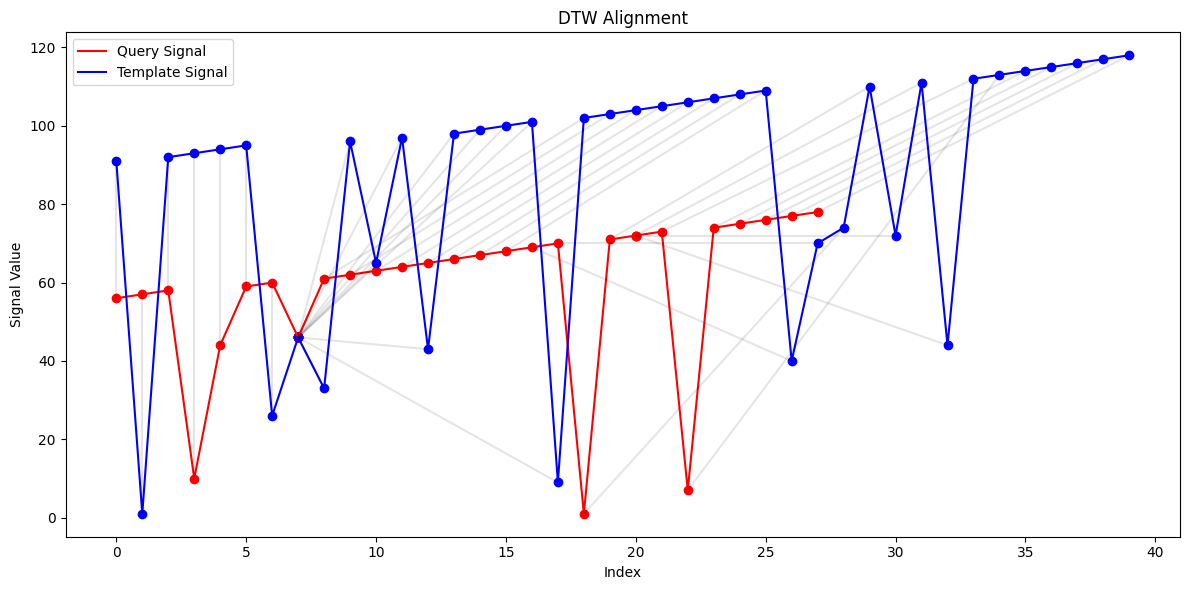

In [10]:
MIMIC_Path = '/lustre/home/almusawiaf/PhD_Projects/MIMIC_resources'
# Parameters
how_many = 500

# Read data
D = pd.read_csv(f'{MIMIC_Path}/DIAGNOSES_ICD.csv')
D, Map = remap_code(D[:how_many])

# Create a dictionary of diagnosis for each patient
P = {}
for [id, code] in D:
    if id not in P.keys():
        P[id] = []
    if code not in P[id]:
        P[id].append(code)
print (P)

# Visualize similarity between patient pairs
Y, note, max_sim = [], [], 0
Keys = list(P.keys())
for i in range(len(Keys) - 1):
    for j in range(i + 1, len(Keys)):
        l1 = P[Keys[i]]
        l2 = P[Keys[j]]
        JS = jaccard_similarity(l1, l2)
        Y.append(JS)

        if JS > max_sim and min(len(l1), len(l2)) > 25:
            max_sim = JS
            note = deepcopy([i, j])

print (max_sim)

# plt.hist(Y, bins = 50)
# plt.show()

# Find the best match with the canonical recursion formula
query    = P[Keys[note[0]]]
template = P[Keys[note[1]]]


alignment = dtw(query, template, dist)
cost, _, _, (ind1, ind2) = deepcopy(alignment)

print (query)
print (template)
print (cost)

viz(query, template, ind1, ind2, 'DTW_Render.png')